In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Load dataset
df = pd.read_csv("Social_Network_Ads.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (400, 5)

Columns:
 Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

Data Types:
 User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object


In [2]:
numeric_cols = ["Age", "EstimatedSalary"]

for col in numeric_cols:
    df.loc[df.sample(frac=0.05, random_state=42).index, col] = np.nan

print("\nMissing Values After Injection:\n", df.isnull().sum())


Missing Values After Injection:
 User ID             0
Gender              0
Age                20
EstimatedSalary    20
Purchased           0
dtype: int64


In [3]:
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
             User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  380.000000       380.000000  400.000000
mean   1.569154e+07   37.565789     70126.315789    0.357500
std    7.165832e+04   10.445152     34412.979114    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   45.250000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [4]:
print("\nGender Distribution:\n", df["Gender"].value_counts())
print("\nTarget Distribution:\n", df["Purchased"].value_counts())


Gender Distribution:
 Gender
Female    204
Male      196
Name: count, dtype: int64

Target Distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


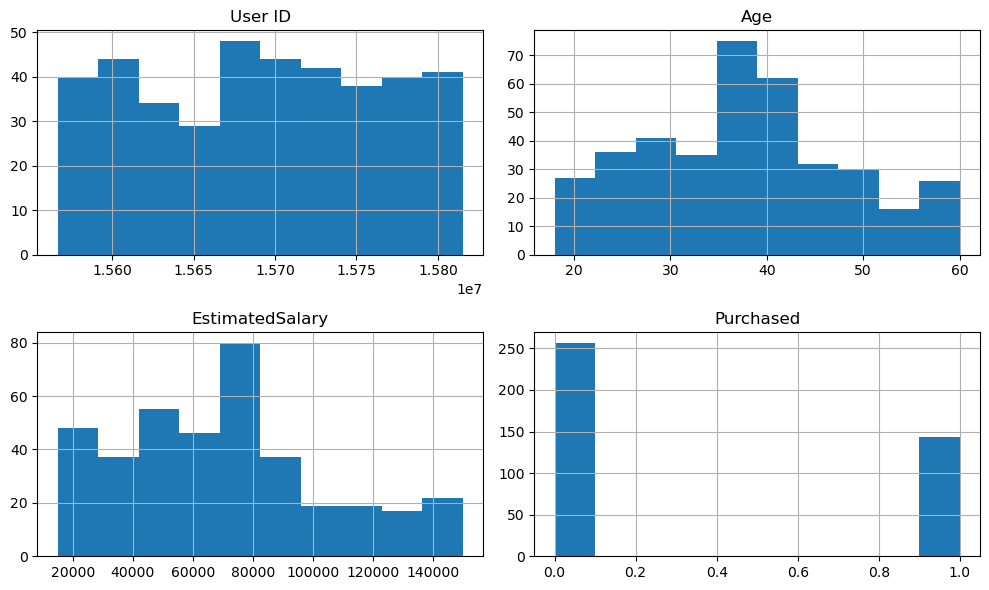

In [5]:
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

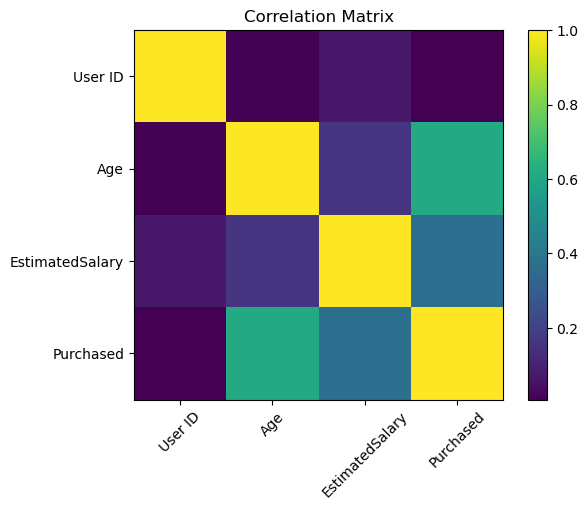

In [6]:
corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [7]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [8]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [10]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers

outlier_indices = set()

for col in ['Age', 'EstimatedSalary']:
    outliers = detect_outliers_iqr(df, col)
    outlier_indices.update(outliers.index)

print("Number of outliers detected:", len(outlier_indices))

Number of outliers detected: 0


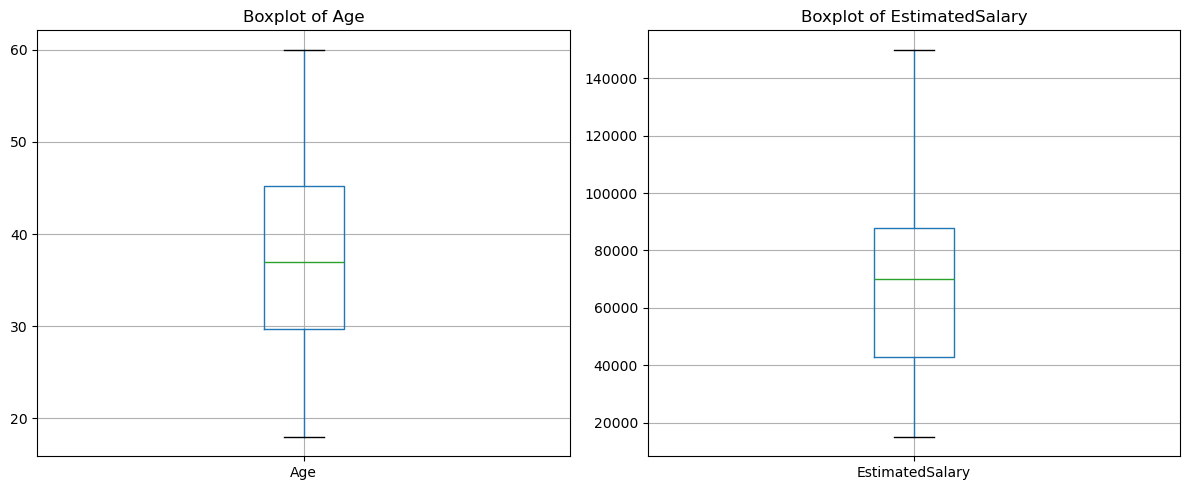

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='Age', ax=axes[0])
axes[0].set_title('Boxplot of Age')

df.boxplot(column='EstimatedSalary', ax=axes[1])
axes[1].set_title('Boxplot of EstimatedSalary')

plt.tight_layout()
plt.show()

In [12]:
df_clean = df.drop(outlier_indices)

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (400, 5)
Cleaned dataset shape: (400, 5)


In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nPreprocessing Completed Successfully!")


Preprocessing Completed Successfully!


In [14]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
y_pred = model.predict(X_test)

In [16]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print("\nTP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)


Confusion Matrix:
 [[65  3]
 [11 21]]

TP: 21
TN: 65
FP: 3
FN: 11


In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.86
Error Rate: 0.14
Precision: 0.875
Recall: 0.65625
